In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [95]:
df = pd.read_csv("bank-full.csv", sep=";")

# overview

In [96]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [97]:
df.shape

(45211, 17)

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [99]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [100]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [101]:
df.select_dtypes(exclude="number").describe()

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [102]:
df.duplicated().sum()

np.int64(0)

## Cleaning

No column has missing values, but some columns contain the word `unknown`.
That is really a missing value, so let's count it.

In [103]:
for col in ["job", "education", "contact", "poutcome"]:
    print(col, (df[col] == "unknown").sum())

job 288
education 1857
contact 13020
poutcome 36959


In [104]:
num_col = df.select_dtypes(include="number").columns
num_col

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='str')

In [105]:
non_num_col = df.select_dtypes(exclude="number").columns
non_num_col

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='str')

In [106]:
df["job"].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [107]:
df["marital"].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [108]:
df["education"].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [109]:
df["default"].value_counts()

default
no     44396
yes      815
Name: count, dtype: int64

In [110]:
df["housing"].value_counts()

housing
yes    25130
no     20081
Name: count, dtype: int64

In [111]:
df["loan"].value_counts()

loan
no     37967
yes     7244
Name: count, dtype: int64

In [112]:
df["contact"].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [113]:
df["poutcome"].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [114]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

Only about 12% of the clients said yes, so the target is imbalanced.

In [115]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

Change yes / no into 1 / 0

In [116]:
for col in ["default", "housing", "loan", "y"]:
    df[col] = df[col].map({"yes": 1, "no": 0})

In [117]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0,unknown,0


# univariate analysis

numeric columns

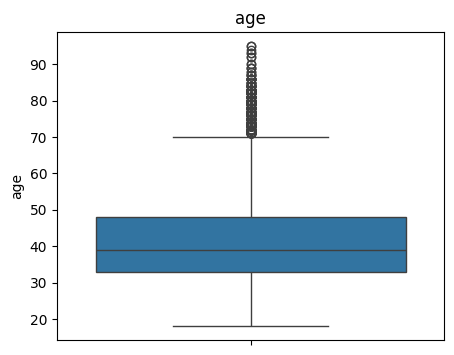

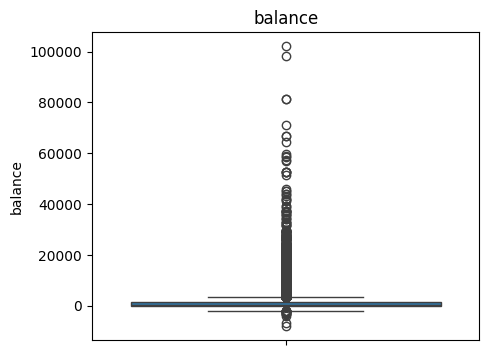

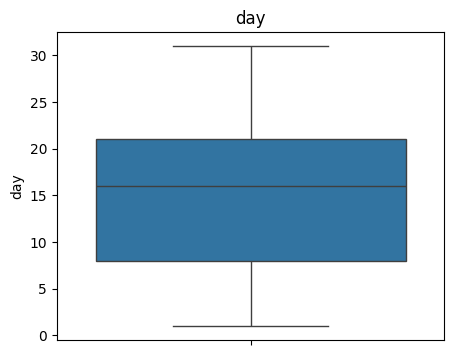

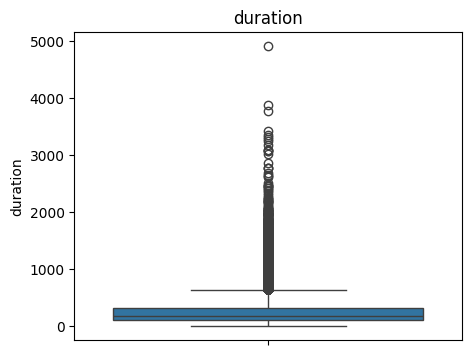

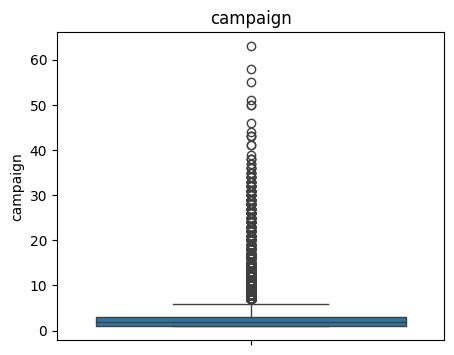

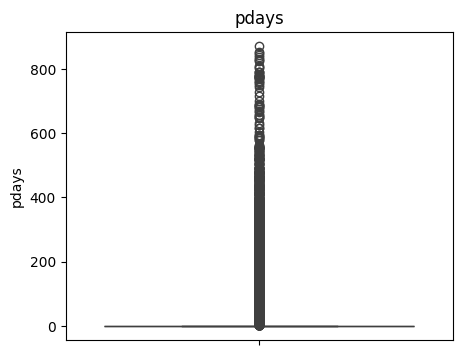

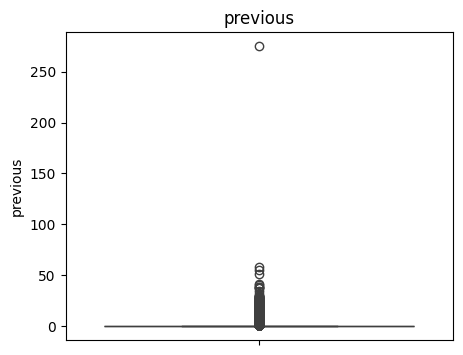

In [118]:
for i in num_col:
    plt.figure(figsize=(5, 4))
    sns.boxplot(y=df[i])
    plt.title(i)
    plt.show()

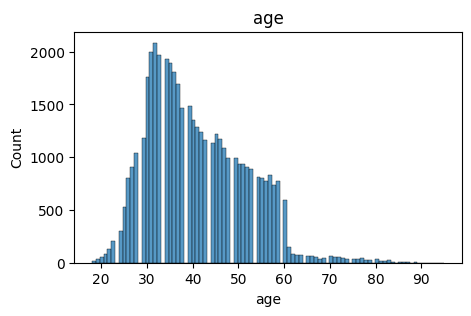

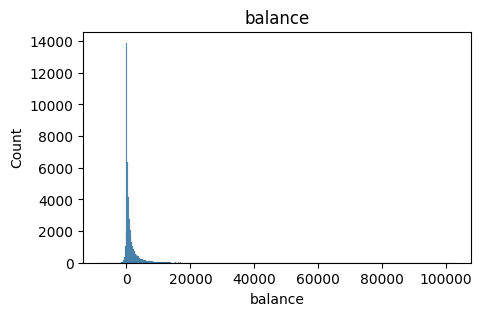

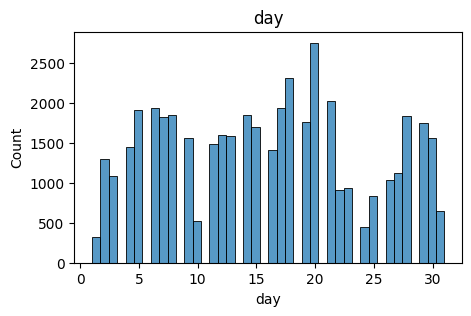

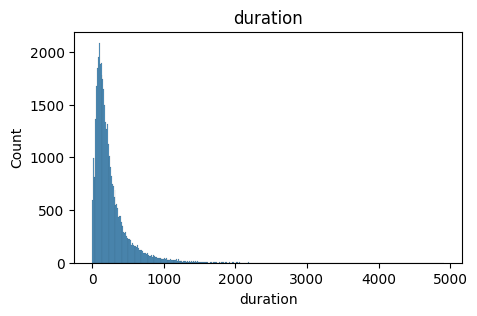

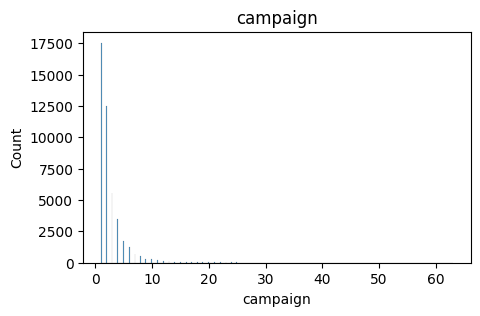

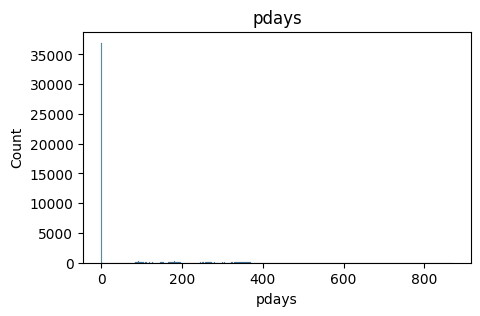

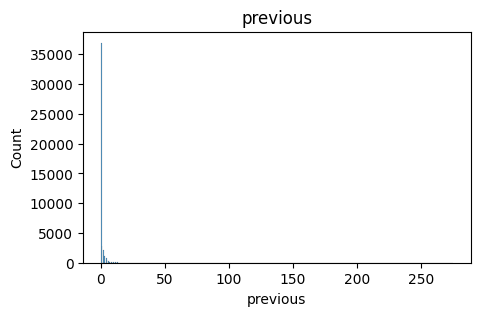

In [119]:
for i in num_col:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[i])
    plt.title(i)
    plt.show()

non numeric columns

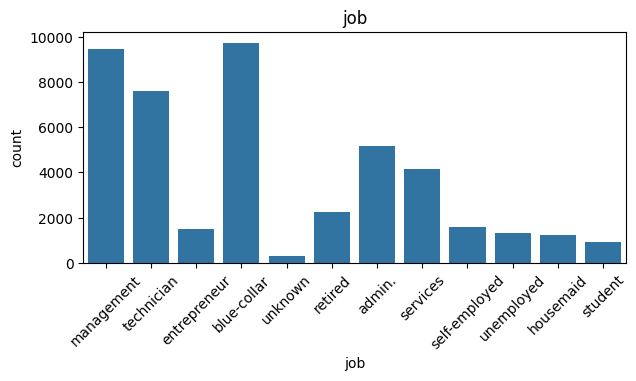

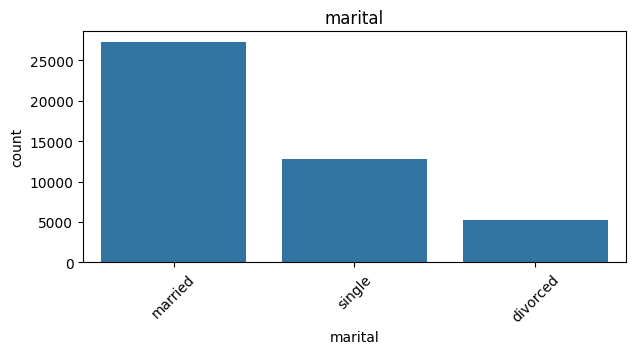

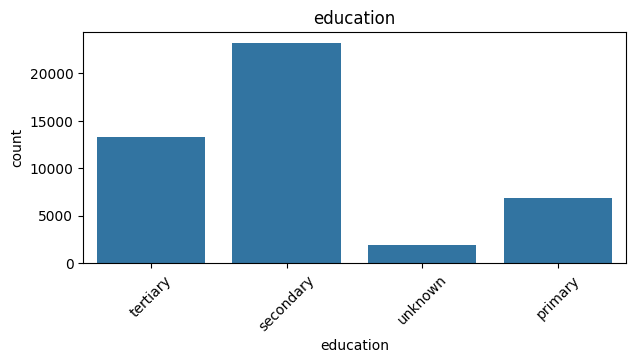

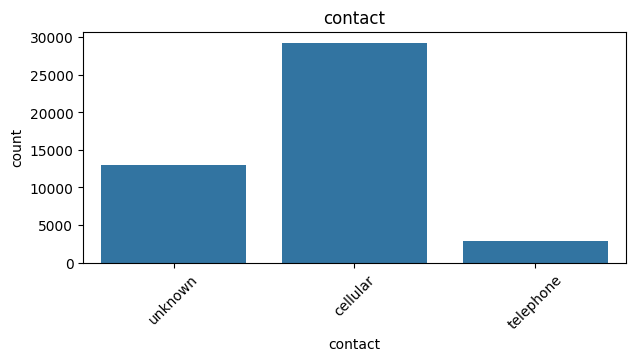

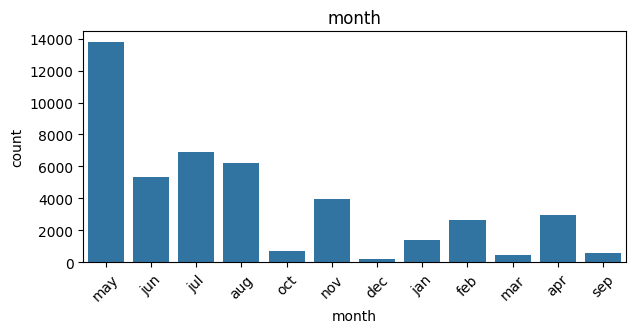

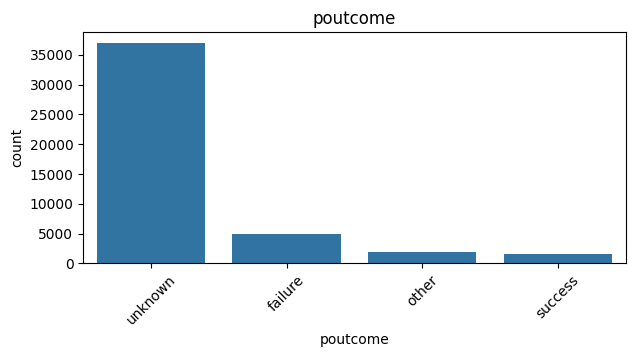

In [120]:
for i in ["job", "marital", "education", "contact", "month", "poutcome"]:
    plt.figure(figsize=(7, 3))
    sns.countplot(x=df[i])
    plt.xticks(rotation=45)
    plt.title(i)
    plt.show()

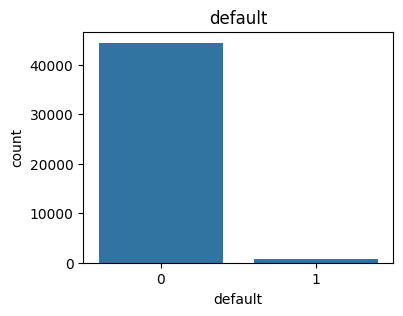

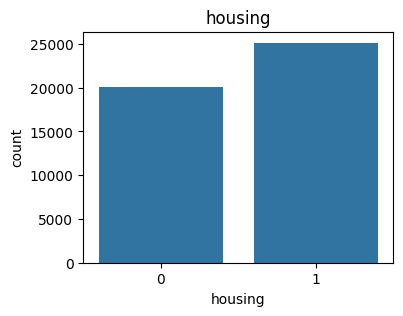

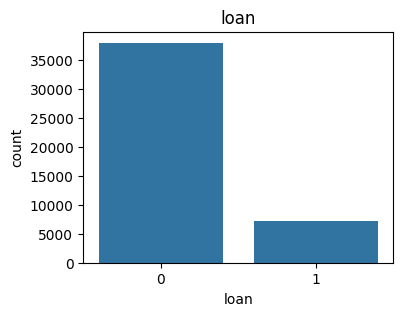

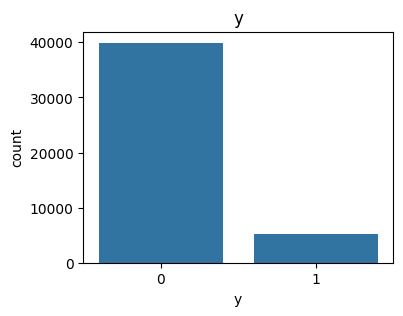

In [121]:
for i in ["default", "housing", "loan", "y"]:
    plt.figure(figsize=(4, 3))
    sns.countplot(x=df[i])
    plt.title(i)
    plt.show()

# outliers

In [122]:

def iqr_outlier(s):
    q1=s.quantile(.25)
    q3 = s.quantile(.75)
    iqr = q3-q1
    low = q1-1.5*iqr
    high = q3+1.5*iqr 
    return ((s<low)|(s>high)).sum(),low,high

In [123]:

report = []
for i in num_col :
    n,low,high = iqr_outlier(df[i])
    
    report.append([i,low,high,n,])

In [124]:
pd.DataFrame(report,columns=['column','lower_bound','iqr_upper','number_of_outliers'])

,column,lower_bound,iqr_upper,number_of_outliers
0,age,10.5,70.5,487
1,balance,-1962.0,3462.0,4729
2,day,-11.5,40.5,0
3,duration,-221.0,643.0,3235
4,campaign,-2.0,6.0,3064
5,pdays,-1.0,-1.0,8257
6,previous,0.0,0.0,8257


In [125]:
df.loc[df["pdays"] == -1]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45203,23,student,single,tertiary,0,113,0,0,cellular,17,nov,266,1,-1,0,unknown,1
45205,25,technician,single,secondary,0,505,0,1,cellular,17,nov,386,2,-1,0,unknown,1
45206,51,technician,married,tertiary,0,825,0,0,cellular,17,nov,977,3,-1,0,unknown,1
45207,71,retired,divorced,primary,0,1729,0,0,cellular,17,nov,456,2,-1,0,unknown,1


In [126]:
df["previous"].sort_values(ascending=False).head()

29182    275
38326     58
44089     55
28886     51
44822     41
Name: previous, dtype: int64

previous = 275 is far away from the rest, it is probably a typing mistake

In [127]:
df[df["previous"] == 275]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
29182,40,management,married,tertiary,0,543,1,0,cellular,2,feb,349,2,262,275,other,0


What happens if we cap the outliers of `balance`?

In [129]:
upper = iqr_outlier(df["balance"])[2]
balance_capped = df["balance"].clip(0, df["balance"].quantile(0.99))

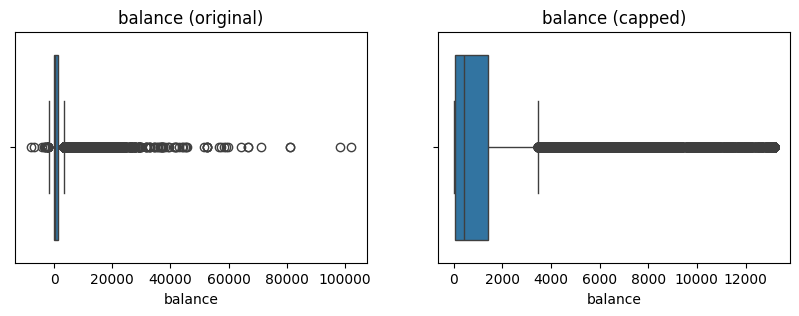

In [130]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["balance"])
plt.title("balance (original)")

plt.subplot(1, 2, 2)
sns.boxplot(x=balance_capped)
plt.title("balance (capped)")

plt.show()

Decision: **we keep the outliers**.
They are real clients (a rich client, a long call...), and a decision tree
only cares about the order of values, so big values do not hurt it.

# bivariate analysis

subscription rate (mean of y) for every category

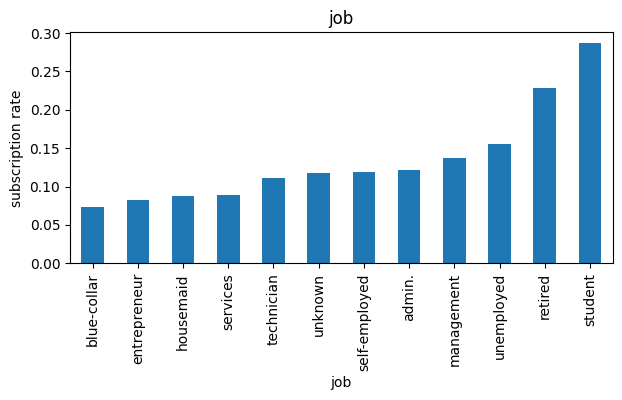

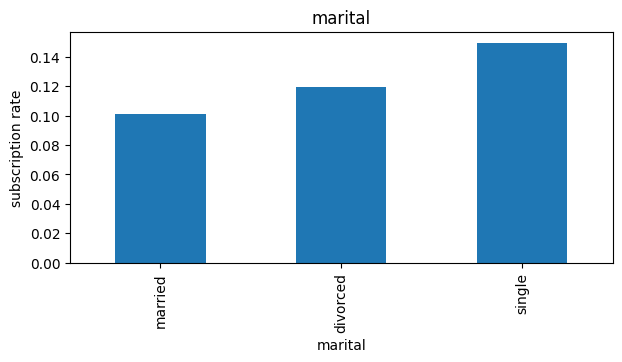

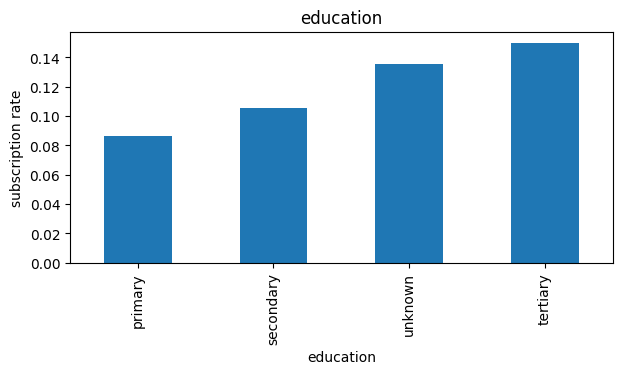

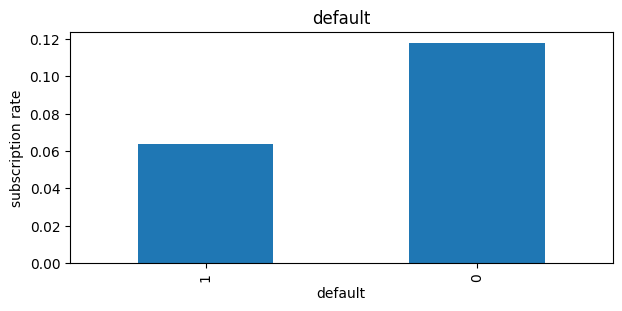

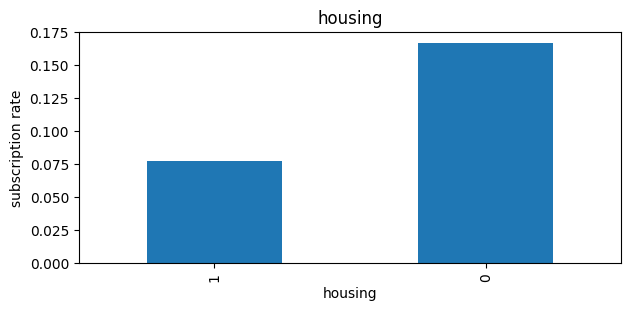

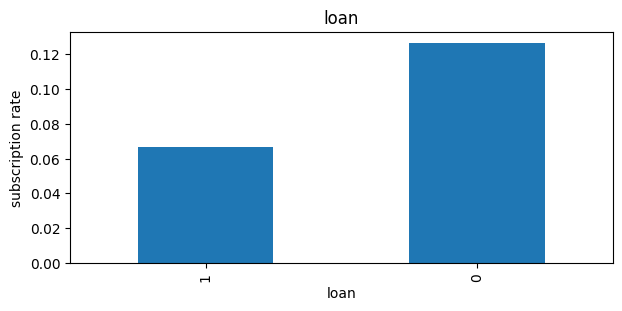

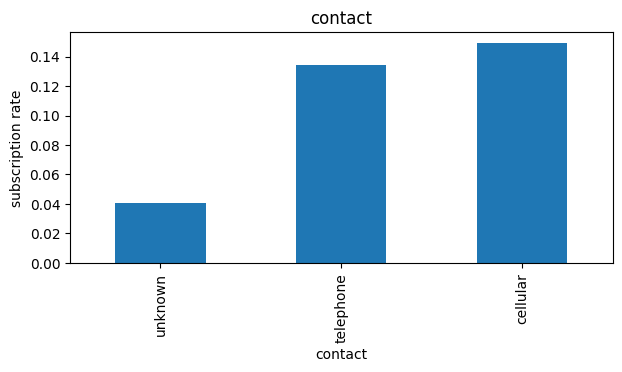

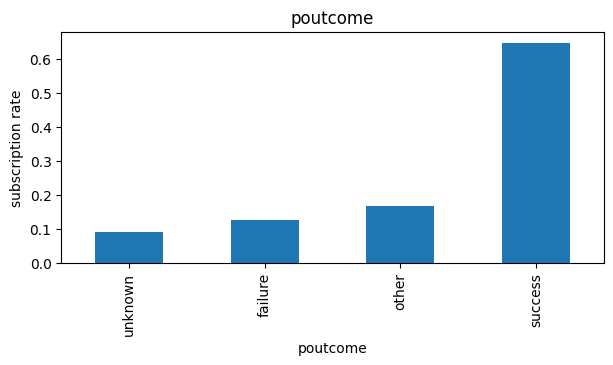

In [ ]:
for i in ["job", "marital", "education", "default", "housing", "loan", "contact", "poutcome"]:
    plt.figure(figsize=(7, 3))
    df.groupby(i)["y"].mean().sort_values().plot(kind="bar")
    plt.ylabel("subscription rate")
    plt.title(i)
    plt.show()

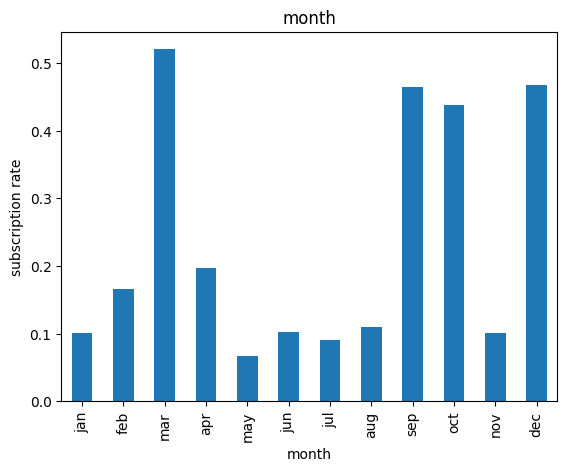

In [ ]:
month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

df.groupby("month")["y"].mean().reindex(month_order).plot(kind="bar")
plt.ylabel("subscription rate")
plt.title("month")
plt.show()

In [ ]:
df["month"].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

March, September, October and December have a high rate, but very few calls were made in those months,
so those rates are not very reliable.

numeric columns against y

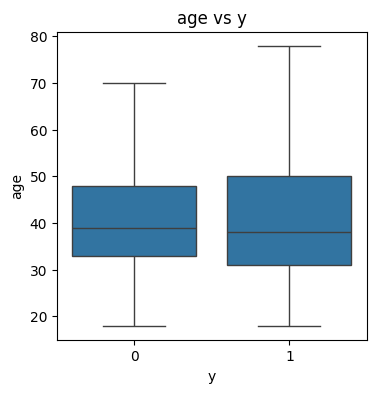

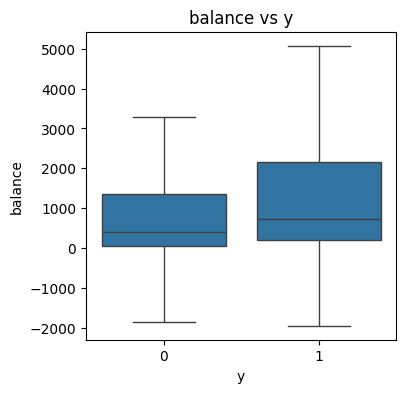

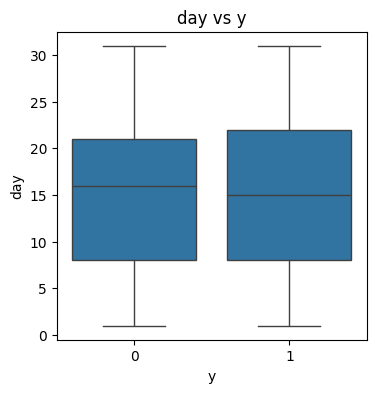

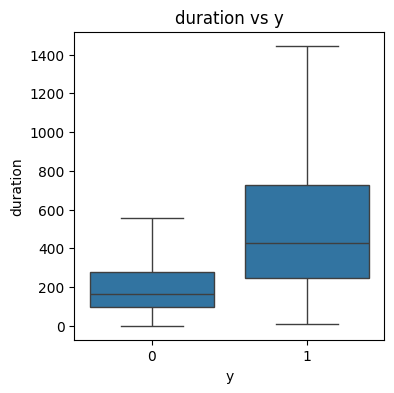

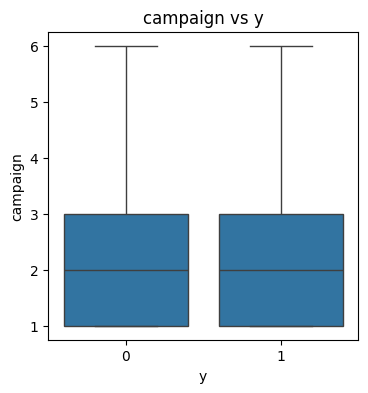

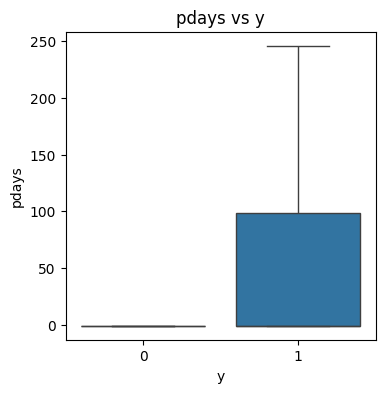

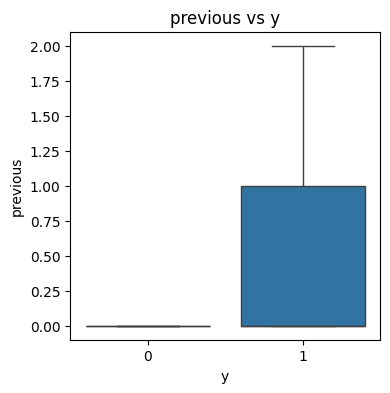

In [ ]:
for i in num_col:
    plt.figure(figsize=(4, 4))
    sns.boxplot(x="y", y=i, data=df, showfliers=False)
    plt.title(i + " vs y")
    plt.show()

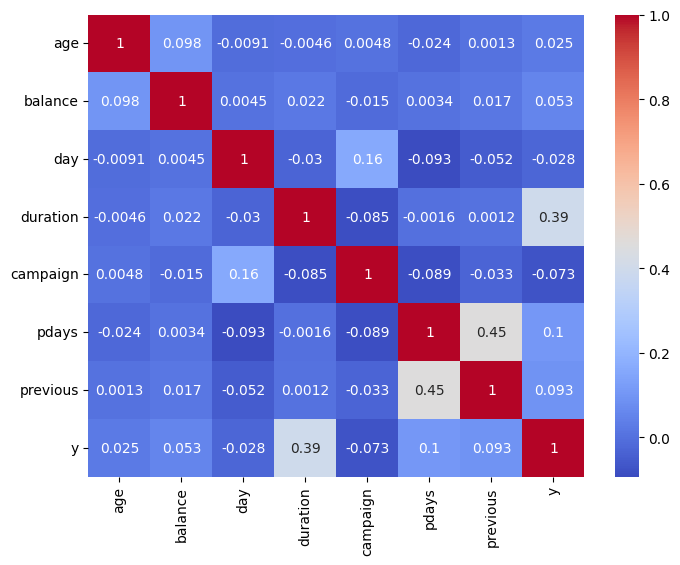

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[list(num_col) + ["y"]].corr(), annot=True, cmap="coolwarm")
plt.show()

duration has the strongest relation with y.

# encoding

non numeric columns need to be converted to numbers before the model

In [131]:
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(categories=[["unknown", "primary", "secondary", "tertiary"]])

In [132]:
df["education"] = ord_enc.fit_transform(df[["education"]])
df["education"]

0        3.0
1        2.0
2        2.0
3        0.0
4        0.0
        ... 
45206    3.0
45207    1.0
45208    2.0
45209    2.0
45210    2.0
Name: education, Length: 45211, dtype: float64

In [133]:
enc = OrdinalEncoder(categories=[["single", "married", "divorced"]])
df["marital"] = enc.fit_transform(df[["marital"]])
df["marital"]

0        1.0
1        0.0
2        1.0
3        1.0
4        0.0
        ... 
45206    1.0
45207    2.0
45208    1.0
45209    1.0
45210    1.0
Name: marital, Length: 45211, dtype: float64

job, contact, month and poutcome have no order, so we use dummy columns (one column per category).

In [134]:
df = pd.get_dummies(df, columns=["job", "contact", "month", "poutcome"], dtype=int)

In [135]:
df.head()

,age,marital,education,default,balance,housing,loan,day,duration,campaign,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,1.0,3.0,0,2143,1,0,5,261,1,...,0,0,1,0,0,0,0,0,0,1
1,44,0.0,2.0,0,29,1,0,5,151,1,...,0,0,1,0,0,0,0,0,0,1
2,33,1.0,2.0,0,2,1,1,5,76,1,...,0,0,1,0,0,0,0,0,0,1
3,47,1.0,0.0,0,1506,1,0,5,92,1,...,0,0,1,0,0,0,0,0,0,1
4,33,0.0,0.0,0,1,0,0,5,198,1,...,0,0,1,0,0,0,0,0,0,1


In [136]:
df.shape

(45211, 44)

In [ ]:
df.dtypes.value_counts()

int64      42
float64     2
Name: count, dtype: int64

# decision tree

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [138]:
X = df.drop("y", axis=1)
y = df["y"]

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [140]:
print(X_train.shape)
print(X_test.shape)

(36168, 43)
(9043, 43)


In [144]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [152]:
y_prd = tree.predict(X_test)

In [153]:

print("test accuracy :", accuracy_score(y_prd, y_test))

test accuracy : 0.875704965166427


In [154]:
print("depth :", tree.get_depth())
print("leaves:", tree.get_n_leaves())

depth : 39
leaves: 2923


In [156]:
print(classification_report(y_test, y_prd))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7952
           1       0.49      0.49      0.49      1091

    accuracy                           0.88      9043
   macro avg       0.71      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



improving model

In [186]:
dfc = df.drop(["duration"],axis=1)

In [187]:
X_new = dfc.drop("y",axis=1)
y_new = dfc["y"]

In [188]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [189]:
tree2 = DecisionTreeClassifier(random_state=42)

In [190]:
tree2.fit(X_train2,y_train2)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [191]:
y_prd2 = tree2.predict(X_test2)

In [192]:
accuracy_score(y_prd2,y_test2)

0.8304766117438903

cv
maxdepth  
gridsearch
stratify 
kfold
crosstab 